In [7]:
!pip install scipy
!pip install scikit-learn

In [8]:
conda update --all

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
ERROR conda.notices.core:wrapper(124): Unable to open cache file: [Errno 13] Permission denied: '/Users/jessicacha/Library/Caches/conda/notices/notices.cache'
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#한글 폰트 설정
system = platform.system()
# Linux / Colab → install Nanum if needed
if system == "Linux":
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"])

# refresh matplotlib font list
fm._load_fontmanager(try_read_cache=False)

# choose font by OS
if system == "Windows":
    font = "Malgun Gothic"
elif system == "Darwin":
    font = "AppleGothic"
else:
    font = "NanumGothic"

plt.rcParams["font.family"] = font
plt.rcParams["axes.unicode_minus"] = False


In [15]:
# 1. 데이터 전처리
#데이터 로드 
df = pd.read_csv('./project_data/pohang_food_by_dong.csv', encoding= 'utf-8')
#print(df)

#분석에 사용할 업종별 비율 컬럼
features = ['한식_ratio', '분식/패스트푸드_ratio', '카페/디저트_ratio', '주점_ratio', '중식_ratio', '일식_ratio', '양식/외국식_ratio', '기타음식_ratio']

#모델에 입력할 숫자 데이터
X = df[features]

#행정동 데이터 전체명 (ex.포항시 북구 양덕동)
df['full_dong'] = df['sigungu'] + ' ' + df['dong']
labels = df['full_dong']

print("AI 학습데이터 shape: ", X.shape)
print(X.head())

AI 학습데이터 shape:  (29, 8)
   한식_ratio  분식/패스트푸드_ratio  카페/디저트_ratio  주점_ratio  중식_ratio  일식_ratio  \
0    0.4934          0.1820        0.1096    0.1318    0.0404    0.0198   
1    0.4205          0.2048        0.1645    0.1024    0.0393    0.0329   
2    0.4852          0.1478        0.0887    0.2340    0.0209    0.0172   
3    0.4662          0.2030        0.1591    0.0977    0.0338    0.0175   
4    0.4540          0.1528        0.1075    0.2136    0.0354    0.0226   

   양식/외국식_ratio  기타음식_ratio  
0        0.0198      0.0033  
1        0.0320      0.0037  
2        0.0037      0.0025  
3        0.0163      0.0063  
4        0.0099      0.0042  


In [29]:
# 2. 데이터 정규화 및 clustering 
#데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#k-means cluster 적용
k=3
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

#PCA 차원축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# PC1, PC2에 각 업종이 얼마나 기여하는지
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)
print(loadings)

[[ 0.90658765 -0.64419423]
 [ 1.71648679  0.59912512]
 [ 1.38142314 -2.09991044]
 [ 0.88931055 -0.18977917]
 [ 1.42318059 -1.26761934]
 [ 1.90101343 -0.07312401]
 [ 1.6432996   0.09337725]
 [ 2.1547892  -0.0807913 ]
 [ 0.63401578 -2.01408655]
 [ 3.22306214  1.16903895]
 [-0.21056694 -0.45995652]
 [-1.18406322 -0.44777709]
 [ 1.26765594  0.01737236]
 [-0.37627223 -0.16979225]
 [ 0.51587203  0.08533963]
 [ 1.62340725 -0.25293267]
 [ 1.77626444  0.8607352 ]
 [-1.89061104 -0.9899863 ]
 [-1.91086604 -0.13834401]
 [-2.21656704 -0.32005821]
 [-0.86084716  1.43243878]
 [ 1.4897873   0.98220915]
 [-2.04708599  0.72182956]
 [-2.44841506 -0.92594168]
 [-2.32186611 -0.64574196]
 [-2.68766464  0.09253107]
 [-1.1072663  -0.25904229]
 [-2.04260109 -1.16652104]
 [-1.24146296  6.09160197]]
                     PC1       PC2
한식_ratio       -0.442549 -0.368548
분식/패스트푸드_ratio  0.472448  0.058071
카페/디저트_ratio   -0.160894  0.514303
주점_ratio        0.393375 -0.325424
중식_ratio       -0.290552  0.363314
일식_rat

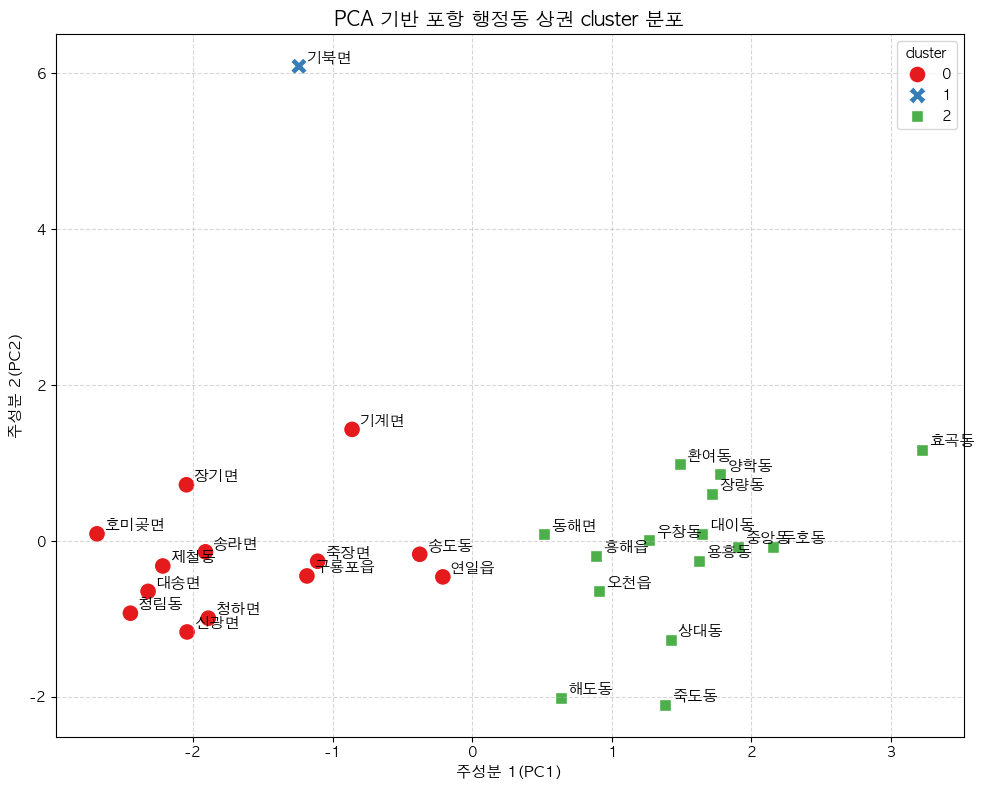

In [30]:
# 3. data clustering visualize
# PCA cluster 산점도 시각화
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df, x='PC1', y='PC2',
    hue='cluster', palette='Set1', s=150, style='cluster'
)

#동네 이름 라벨
for i, row in df.iterrows():
    plt.text(row['PC1']+ 0.05, row['PC2']+ 0.05, row['dong'], fontsize=11, fontweight='bold')
plt.title('PCA 기반 포항 행정동 상권 cluster 분포', fontsize=14, fontweight='bold')
plt.xlabel('주성분 1(PC1)', fontsize=11)
plt.ylabel('주성분 2(PC2)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_cluster_plot.png', dpi=300)
plt.show()

<Figure size 1200x600 with 0 Axes>

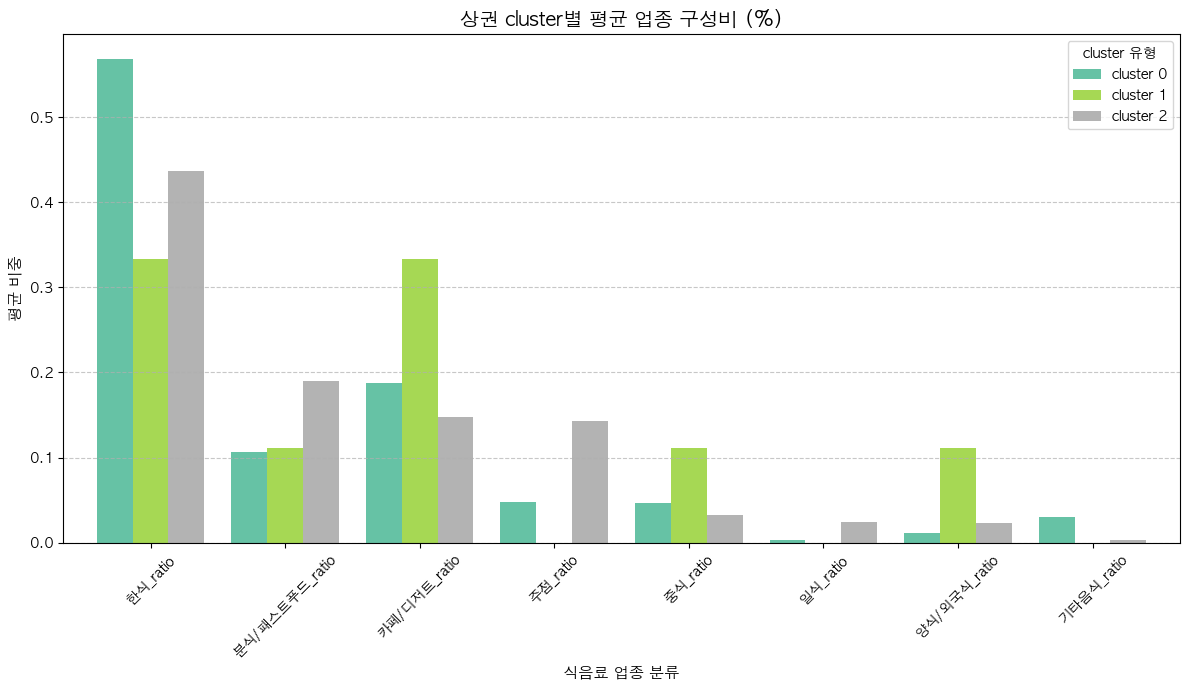

In [31]:
# cluster별 업종 분석
#각 클러스터 그룹별, 8개 업종 비율의 평균
cluster_profile = df.groupby('cluster')[features].mean()

plt.figure(figsize=(12,6))
cluster_profile.T.plot(kind='bar', figsize=(12,7), cmap='Set2', width=0.8)
plt.title('상권 cluster별 평균 업종 구성비 (%)', fontsize=14, fontweight='bold')
plt.xlabel('식음료 업종 분류', fontsize=11)
plt.ylabel('평균 비중', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='cluster 유형', labels=[f'cluster {i}' for i in range(k)])
plt.tight_layout()
plt.savefig('cluster_profile.png', dpi=300)
plt.show()


In [35]:
# 클러스터별 어떤 동네가 속하는지
for c in range(3):
    print(f"\n=== Cluster {c} ===")
    print(df[df['cluster'] == c]['full_dong'].values)

df.to_csv('cluster_result.csv', index=False, encoding='utf-8-sig')
print()
print("cluster 분석 결과, csv 생성 완료.")


=== Cluster 0 ===
['포항시 남구 연일읍' '포항시 남구 구룡포읍' '포항시 남구 송도동' '포항시 북구 청하면' '포항시 북구 송라면'
 '포항시 남구 제철동' '포항시 북구 기계면' '포항시 남구 장기면' '포항시 남구 청림동' '포항시 남구 대송면'
 '포항시 남구 호미곶면' '포항시 북구 죽장면' '포항시 북구 신광면']

=== Cluster 1 ===
['포항시 북구 기북면']

=== Cluster 2 ===
['포항시 남구 오천읍' '포항시 북구 장량동' '포항시 북구 죽도동' '포항시 북구 흥해읍' '포항시 남구 상대동'
 '포항시 북구 중앙동' '포항시 남구 대이동' '포항시 북구 두호동' '포항시 남구 해도동' '포항시 남구 효곡동'
 '포항시 북구 우창동' '포항시 남구 동해면' '포항시 북구 용흥동' '포항시 북구 양학동' '포항시 북구 환여동']

cluster 분석 결과, csv 생성 완료.
